In [1]:
import torch
import scipy.io
import mne
import sklearn
import os 
import random
import scipy.linalg
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb

from itertools import chain, product

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from mne_features.feature_extraction import FeatureExtractor
from torch.utils.data import random_split, DataLoader, Dataset
from torch.nn import functional as F
from torch import nn
from pytorch_lightning.core.module import LightningModule
from pytorch_lightning.loggers import TensorBoardLogger
from scipy.stats import norm, wasserstein_distance


C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Assess whether GPU is availble
if torch.cuda.is_available():
    print("PyTorch is using the GPU.")
    print("Device name - ", torch.cuda.get_device_name(torch.cuda.current_device()))
else: 
    print("PyTorch is not using the GPU.")
    


PyTorch is using the GPU.
Device name -  NVIDIA GeForce RTX 3080


In [3]:
# Import Utility functions frmo diffrent notebooks
import import_ipynb
from IEEE_data import extract_ieee_data, LazyProperty, data_4class
from CHIST_ERA_data import *
from Utils import *

importing Jupyter notebook from IEEE_data.ipynb
importing Jupyter notebook from CHIST_ERA_data.ipynb
importing Jupyter notebook from Utils.ipynb


'coda' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
def mneFeatures(X, fs):
    selected_funcs = ['line_length', 'kurtosis', 'skewness', 'pow_freq_bands', 'spect_slope',
                     'spect_entropy', 'spect_edge_freq', 'mean', 'variance', 'ptp_amp']
    params = {'pow_freq_bands__freq_bands' : np.array([[8, 10],
                                                      [10,12],
                                                      [9, 13],
                                                      [12, 20],
                                                      [20, 25],
                                                      [25, 30]])}
    fe = FeatureExtractor(sfreq=fs, selected_funcs=selected_funcs, params=params)

    X_features = fe.fit_transform(X)
    return X_features

In [5]:
def mneFeatures(X, fs):
    selected_funcs = ['line_length', 'kurtosis', 'skewness', 'pow_freq_bands']
    params = {'pow_freq_bands__freq_bands' : np.array([[8, 10],
                                                      [10,12],
                                                      [9, 13],
                                                      [12, 20],
                                                      [20, 25],
                                                      [25, 30]])}
    fe = FeatureExtractor(sfreq=fs, selected_funcs=selected_funcs, params=params)

    X_features = fe.fit_transform(X)
    return X_features

In [6]:
def mne_classifier(signal, labels, fs, zero_time, classifier = False):
    # cut signal before + after
    signal_before = signal[:, :, :fs*zero_time]
    signal_after = signal[:, :, fs*zero_time:]
    # Get features
    features_before = mneFeatures(signal_before, fs)
    features_after = mneFeatures(signal_after, fs)
    
#     X = np.hstack((features_before, features_after))
    X = np.divide(features_before, features_after)
    if classifier:
        score = features_classfier(X, labels, 5, classifier)
        return score
    else:
        score, clf = features_classfier(X, labels, 5, classifier)
    return score, clf


In [7]:
def features_classfier(X, y, cv_N = 5, classifier = False):
    
    scores = []
    
    if classifier:
        y_pred = classifier.predict(X)
        acc = sklearn.metrics.accuracy_score(y, y_pred)
        return acc
    
    else:
        # Assemble a classifier

        clf = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
        scores = cross_val_score(clf, X, y, cv=cv_N, n_jobs=1)
        clf.fit(X, y)
        return np.mean(scores), clf

In [8]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    ly += yerr[num1]
    ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh+0.05)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

In [9]:
def original_day_classifier(eeg_list):
    # Use day zero classifier for classifying the reconstructed eeg per day
    
    residuals = []
    labels = []
    for day_i in range(len(eeg_list)):
        # Get data
        signal_test_data = EEGDataSet_signal(dictListStacked, [day_i, day_i+1])
        signal_test, y_test = signal_test_data.getAllItems()
       
        # Get residuals
        residuals.append(signal_test.detach().numpy())
        labels.append(np.ones((1, signal_test.shape[0])) * day_i)
    labels= np.hstack(labels)
    labels = np.squeeze(labels)
    residuals = np.vstack(residuals)

    score, _ = csp_score(np.float64(residuals), labels, cv_N = 5, classifier = False)
    return score

In [10]:
def reconstruction_day_classifier(AE_model, eeg_list):
    # Use day zero classifier for classifying the reconstructed eeg per day
    
    residuals = []
    labels = []
    for day_i in range(len(eeg_list)):
        # Get data
        signal_test_data = EEGDataSet_signal(dictListStacked, [day_i, day_i+1])
        signal_test, y_test = signal_test_data.getAllItems()

        # reconstruct EEG AE
        rec_signal = AE_model(signal_test).detach().numpy()        
        # Get residuals
        residuals.append(rec_signal)
        labels.append(np.ones((1, signal_test.shape[0])) * day_i)
    labels= np.hstack(labels)
    labels = np.squeeze(labels)
    residuals = np.vstack(residuals)

    score, _ = csp_score(np.float64(residuals), labels, cv_N = 5, classifier = False)
    return score

In [11]:
def residual_day_classifier(AE_model, eeg_list):
    # Use day zero classifier for classifying the residuals per day
    
    residuals = []
    labels = []
    for day_i in range(len(eeg_list)):
        # Get data
        signal_test_data = EEGDataSet_signal(dictListStacked, [day_i, day_i+1])
        signal_test, y_test = signal_test_data.getAllItems()

        # reconstruct EEG AE
        rec_signal = AE_model(signal_test).detach().numpy()        
        # Get residuals
        residuals.append((signal_test - rec_signal).detach().numpy())
        labels.append(np.ones((1, signal_test.shape[0])) * day_i)
    labels= np.hstack(labels)
    labels = np.squeeze(labels)
    residuals = np.vstack(residuals)

    score, _ = csp_score(np.float64(residuals), labels, cv_N = 5, classifier = False)
    return score

### Datset and Model classes

In [12]:
class EEGDataSet_signal(Dataset):
    def __init__(self, EEGDict, days_range=[0,1]):
        
        # Concat dict      
        X, y = self.concat(EEGDict, days_range)
        

        
        # Convert from numpy to tensor
        self.X = torch.tensor(X)
        self.n_samples = self.X.shape[0]
        self.n_channels = self.X.shape[1]
        self.y = y

        
    def __getitem__(self, index):
        return self.X[index].float(), self.y[index]
    
    def __len__(self):
        return self.n_samples
    
    def getAllItems(self):
        return self.X.float() , self.y
    
    def concat(self, EEGDict, days_range):
        X = []
        y = []
        for d in dictListStacked[days_range[0]:days_range[1]]:
            X.append(d['segmentedEEG'])
            y.append(d['labels'])

        X = np.asarray(X)
        y = np.asarray(y)
        X = np.concatenate(X)
        y = np.concatenate(y)
        return X, y

In [112]:
class convolution_AE(LightningModule):
    def __init__(self, input_channels, learning_rate=1e-3, filters_n = [32, 16, 4], pca_W = False):
        super().__init__()
        self.input_channels = input_channels
        self.filters_n = filters_n
        self.learning_rate = learning_rate
        self.float()
        self.l1_filters, self.l2_filters, self.l3_filters = self.filters_n

        self.pca_W = pca_W
        ### The model architecture ###
        
        # Encoder
        self.encoder = nn.Sequential(
        nn.Conv1d(self.input_channels, self.l1_filters, kernel_size=25, stride=5, padding=1),
        nn.LeakyReLU(),
        nn.Conv1d(self.l1_filters, self.l2_filters, kernel_size=10, stride=2, padding=1),
        nn.LeakyReLU(),
        nn.Conv1d(self.l2_filters, self.l3_filters, kernel_size=5, stride=2, padding=1),
        nn.LeakyReLU()
        )
                
        # Decoder
        self.decoder = nn.Sequential(
        # IMPORTENT - on the IEEE dataset - the output padding needs to be 1 in the row below -on CHIST-ERA its 1
        nn.ConvTranspose1d(self.l3_filters, self.l2_filters, kernel_size=5, stride=2, padding=1, output_padding=0),
        nn.LeakyReLU(),
        nn.ConvTranspose1d(self.l2_filters, self.l1_filters, kernel_size=10, stride=2, padding=1, output_padding=0),
        nn.LeakyReLU(),
        nn.ConvTranspose1d(self.l1_filters, self.input_channels, kernel_size=25, stride=5, padding=1, output_padding=2),
        )

        
        # Classifier
        self.classiffier(
        nn.MaxPool1d(self.l3_filters, 4, kernel_size=15, stride=3, padding=1),
        nn.LeakyReLU(),
        nn.Linear(128, a),
        
        )
        
        
        
        
    def forward(self, x):
        # Forward through the layeres
        # Encoder
        x = self.encoder(x)

        # Decoder
        x = self.decoder(x)
        return x
    
    def encode(self, x):
        # Forward through the layeres
        # Encoder
        x = self.encoder(x)
        return x
    
    def maxPool(self, x, size, stride):
        pool = nn.MaxPool1d(size, stride)
        pooled_x = pool(x)
        pooled_x = torch.flatten(pooled_x, 1)
        return pooled_x
        
    def training_step(self, batch, batch_idx):
        x, y = batch
        # Recountruction
        encoded = self.encode(x)
        logits = self.decoder(encoded)
        cpu_logits = np.float64(logits.detach().cpu().numpy())
        # Loss function
        try:
            if len(self.pca_W.shape)>0:
                rec_error = pca_error(self.pca_W, logits)
                loss = F.mse_loss(logits, x) + 0*rec_error
        except:
#             svm = sklearn.ensemble.RandomForestClassifier()
#             spliter = sklearn.model_selection.StratifiedKFold(n_splits=2)
#             score = sklearn.model_selection.cross_val_score(svm, cpu_feat, y.cpu().numpy(), cv=spliter)
            score, _ = csp_score(cpu_logits, y.cpu().numpy(), cv_N = 5, classifier = False)
            loss = F.mse_loss(logits, x) * (1 - score)
        return loss
    
        
    def configure_optimizers(self):
        # Optimizer
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

# Training loop function

In [113]:
def training_loop(train_days, dictListStacked, fs, ae_learning_rt, convolution_filters, batch_sz, zero_time, epoch_n):
    
    device = torch.device("cuda")
    # Logger
    logger = TensorBoardLogger('tb_logs', name='EEG_Logger', log_every_n_steps=4)

    # Train Dataset
    signal_data = EEGDataSet_signal(dictListStacked, train_days)
    signal_data_loader = DataLoader(dataset=signal_data, batch_size=batch_sz, shuffle=True, num_workers=0)
    x, y = signal_data.getAllItems()

    # Train model on training day
    day_zero_AE = convolution_AE(signal_data.n_channels, ae_learning_rt, filters_n=convolution_filters)
    day_zero_AE.to(device)
    trainer_1 = pl.Trainer(max_epochs=epoch_n, logger=logger, accelerator='gpu', devices=-1)
    trainer_1.fit(day_zero_AE, train_dataloaders=signal_data_loader)
    
    score_ae, day_zero_AE_clf = fbcsp_score(np.float64(day_zero_AE(x).detach().numpy()), y, cv_N=5, classifier=False, fs=fs, m_filters=26, n_select=n_feature_select)
    score_bench, day_zero_bench_clf = fbcsp_score(np.float64(x.detach().numpy()), y, cv_N=5, classifier=False, fs=fs, m_filters=26, n_select=n_feature_select)

    # Loop :)
    bench_diff_day_score = []
    bench_same_day_score = []
    AE_diff_day_score = []
    
    # Append day zero score
    bench_diff_day_score.append(score_bench)
    bench_same_day_score.append(score_bench)
    AE_diff_day_score.append(score_ae)

    for i in range(train_days[1], len(dictListStacked)):
        test_days = [i, i+1]

        # Create test Datasets
        signal_test_data = EEGDataSet_signal(dictListStacked, test_days)
        signal_test_data_loader = DataLoader(dataset=signal_test_data, batch_size=8, shuffle=True, num_workers=0)

        # get data
        signal_test, y_test = signal_test_data.getAllItems()
        # reconstruct EEG using day 0 AE
        rec_signal_zero = day_zero_AE(signal_test).detach().numpy()


        # Use models
        print('Day #',i)
        same_day_score, _ = fbcsp_score(np.float64(signal_test.detach().numpy()), y_test, cv_N=5, classifier = False, fs=fs, m_filters=26, n_select=n_feature_select)
        print('Bench-\nIn day accuracy: ', same_day_score)
        bench_diff_day = fbcsp_score(np.float64(signal_test.detach().numpy()), y_test, cv_N=5, classifier=day_zero_bench_clf, fs=fs, m_filters=26, n_select=n_feature_select)
        print('Different day accuracy: ',bench_diff_day)

        AE_diff_day = fbcsp_score(rec_signal_zero, y_test, cv_N=5, classifier=day_zero_AE_clf, fs=fs, m_filters=26, n_select=n_feature_select)
        print('AE-\nDifferent day accuracy: ', AE_diff_day, '\n')

        # Append each day results
        AE_diff_day_score.append(AE_diff_day)
        bench_diff_day_score.append(bench_diff_day) 
        bench_same_day_score.append(same_day_score)
    
    return bench_same_day_score, bench_diff_day_score, AE_diff_day_score, day_zero_AE

### Load the files - IEEE

In [115]:
tmin = 0
tmax = 6
select_label = [1,4]
zero_time = 2

filterLim = [4,40] # In Hz

fs = 500
ae_learning_rt = 1e-3
n_epochs = 250
batch_sz = 64
convolution_filters = [8,16,32]

n_feature_select = 100

amp_thresh = 250
min_trials = 10

In [116]:
sub = 'A3'

try:
    assert dictListStacked[0]['sub'] == sub
except:
    dictListStacked = extract_ieee_data(sub, filterLim, tmin, tmax, select_label, data_dir = 'data/ieee_dataset/')

In [117]:

# Remove noisy trials using amplitude threshold
new_dict_list = []
for i, D in enumerate(dictListStacked):
    max_amp = np.amax(np.amax(D['segmentedEEG'], 2), 1)
    min_amp = np.amin(np.amin(D['segmentedEEG'], 2), 1)
    max_tr = max_amp > amp_thresh 
    min_tr = min_amp < -amp_thresh
    noisy_trials = [a or b for a, b in zip(max_tr, min_tr)]
    D['segmentedEEG'] = np.delete(D['segmentedEEG'], noisy_trials,axis=0)
    D['labels'] = np.delete(D['labels'], noisy_trials,axis=0)
    if D['segmentedEEG'].shape[0] > min_trials:
            new_dict_list.append(D)

dictListStacked = new_dict_list


In [118]:
dictListStacked[0]['segmentedEEG'].shape

(120, 26, 3000)

# Run training

In [100]:
import logging
import time
logging.getLogger("lightning").setLevel(logging.ERROR)

# Sub 206 - 200 epochs
train_days=[0,1]

start = time.time()

bench_same_day_score, bench_diff_day_score, AE_diff_day_score, _ = \
training_loop(train_days, dictListStacked, fs, ae_learning_rt, convolution_filters, batch_sz, zero_time, n_epochs)

print(time.time() - start)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params
---------------------------------------
0 | encoder | Sequential | 9.1 K 
1 | decoder | Sequential | 9.1 K 
---------------------------------------
18.2 K    Trainable params
0         Non-trainable params
18.2 K    Total params
0.073     Total estimated model params size (MB)
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packag

Epoch 10:  25%|█████████████                                       | 1/4 [00:00<00:02,  1.23it/s, loss=10.4, v_num=234]0.5190476190476191 tensor(21.1134, device='cuda:0', grad_fn=<MseLossBackward0>)


Epoch 20:  50%|██████████████████████████                          | 2/4 [00:01<00:01,  1.22it/s, loss=7.36, v_num=234]0.4476190476190476 tensor(16.3671, device='cuda:0', grad_fn=<MseLossBackward0>)


Epoch 30:  75%|███████████████████████████████████████             | 3/4 [00:02<00:00,  1.21it/s, loss=6.07, v_num=234]0.44999999999999996 tensor(13.8263, device='cuda:0', grad_fn=<MseLossBackward0>)


Epoch 41:  25%|█████████████                                       | 1/4 [00:00<00:02,  1.21it/s, loss=5.76, v_num=234]0.44285714285714284 tensor(12.0702, device='cuda:0', grad_fn=<MseLossBackward0>)


...

Epoch 186:  50%|█████████████████████████▌                         | 2/4 [00:01<00:01,  1.15it/s, loss=1.96, v_num=234]0.3142857142857143 tensor(5.4518, device='cuda:0', grad_fn=<MseLossBackward0>)


Epoch 196:  75%|██████████████████████████████████████▎            | 3/4 [00:02<00:00,  1.18it/s, loss=1.66, v_num=234]0.4099999999999999 tensor(4.1715, device='cuda:0', grad_fn=<MseLossBackward0>)


Epoch 199: 100%|███████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.24it/s, loss=1.79, v_num=234]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|███████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.24it/s, loss=1.79, v_num=234]
Day # 1
Epoch 2:  88%|█████████████████████████████████████████████▌      | 7/8 [17:18<02:28, 148.40s/it, loss=14.5, v_num=232]
Bench-
In day accuracy:  0.9114624505928853
Different day accuracy:  0.5221238938053098
AE-
Different day accuracy:  0.672566371681416 

Day # 2
Bench-
In day accuracy:  0.9333333333333333
Different day accuracy:  0.5
AE-
Different day accuracy:  0.5777777777777777 

Day # 3
Bench-
In day accuracy:  1.0
Different day accuracy:  0.4857142857142857
AE-
Different day accuracy:  0.7428571428571429 

Day # 4
Bench-
In day accuracy:  0.9833333333333332
Different day accuracy:  0.4957983193277311
AE-
Different day accuracy:  0.8235294117647058 

Day # 5
Bench-
In day accuracy:  0.9652173913043478
Different day accuracy:  0.49557522123893805
AE-
Different day accuracy:  0.6283185840707964 

Day # 6
Bench-
In day accuracy:  1.0
Different day accuracy:

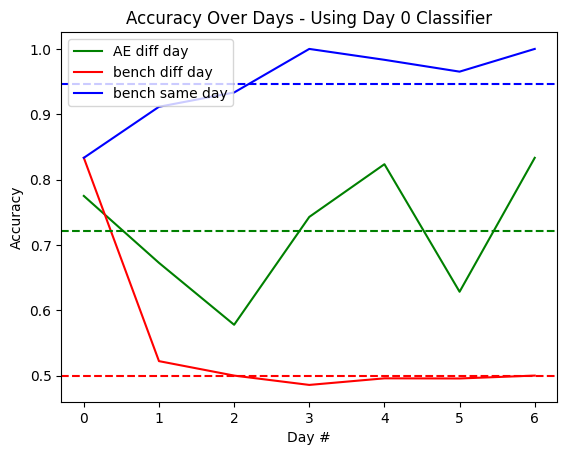

In [102]:
# 163.70045971870422
# 181.36930656433105

# Start from which day to plot?
plot_from = 0

# Plot
plt.plot(range(plot_from, plot_from + len(AE_diff_day_score[plot_from:])), AE_diff_day_score[plot_from:], label='AE diff day', color='g')
plt.plot(range(plot_from, plot_from + len(AE_diff_day_score[plot_from:])), bench_diff_day_score[plot_from:], label='bench diff day', color='r')
plt.plot(range(plot_from, plot_from + len(AE_diff_day_score[plot_from:])), bench_same_day_score[plot_from:], label='bench same day', color='b')

plt.axhline(y=np.mean(AE_diff_day_score[plot_from:]), color='g', linestyle='--')
plt.axhline(y=np.mean(bench_diff_day_score[1:]), color='r', linestyle='--')
plt.axhline(y=np.mean(bench_same_day_score[plot_from:]), color='b', linestyle='--')

plt.title('Accuracy Over Days - Using Day 0 Classifier')
plt.xlabel('Day #')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loop over all files

In [119]:
# Corrupted files - A1, A4(maybe?), A5(maybe?), A8(maybe?), S1(maybe?), S4(maybe?)
sub_list = ['A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8','S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8','S9','S10','S11', 'S12']
           

same_list = []
diff_list = []
AE_list = []
day_classification_score = []
for sub in sub_list:
    try:
        dictListStacked = extract_ieee_data(sub, filterLim, tmin, tmax, select_label, data_dir = 'data/ieee_dataset/')
    except:
        continue
    # Remove noisy trials using amplitude threshold
    new_dict_list = []
    for i, D in enumerate(dictListStacked):
        max_amp = np.amax(np.amax(D['segmentedEEG'], 2), 1)
        min_amp = np.amin(np.amin(D['segmentedEEG'], 2), 1)
        max_tr = max_amp > amp_thresh 
        min_tr = min_amp < -amp_thresh
        noisy_trials = [a or b for a, b in zip(max_tr, min_tr)]
        D['segmentedEEG'] = np.delete(D['segmentedEEG'], noisy_trials,axis=0)
        D['labels'] = np.delete(D['labels'], noisy_trials,axis=0)
        if D['segmentedEEG'].shape[0] > min_trials:
                new_dict_list.append(D)

    dictListStacked = new_dict_list
        
    train_days=[0,1]
    
    bench_same_day_score, bench_diff_day_score, AE_diff_day_score, day_zero_AE = \
    training_loop(train_days, dictListStacked, fs, ae_learning_rt, convolution_filters, batch_sz, zero_time, n_epochs)
    
    # Day classfication using residuals original and recontrusted EEG
    res_score = residual_day_classifier(day_zero_AE, dictListStacked)
    rec_score = reconstruction_day_classifier(day_zero_AE, dictListStacked)
    orig_score = original_day_classifier(dictListStacked)
    day_classification_score.append([orig_score, rec_score, res_score])
    
    # Add results
    same_list.append(bench_same_day_score) 
    diff_list.append(bench_diff_day_score)
    AE_list.append(AE_diff_day_score)
    print(sub)
    print(np.mean(bench_same_day_score))
    print(np.mean(bench_diff_day_score))
    print(np.mean(AE_diff_day_score))


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params
---------------------------------------
0 | encoder | Sequential | 9.1 K 
1 | decoder | Sequential | 9.1 K 
---------------------------------------
18.2 K    Trainable params
0         Non-trainable params
18.2 K    Total params
0.073     Total estimated model params size (MB)
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packag

Epoch 249: 100%|███████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.51s/it, loss=2.07, v_num=235]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|███████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.51s/it, loss=2.07, v_num=235]
Day # 1
Bench-
In day accuracy:  0.825
Epoch 89:  25%|████████████                                    | 1/4 [36:47<1:50:23, 2207.79s/it, loss=2.72, v_num=233]
Different day accuracy:  0.5
AE-
Different day accuracy:  0.7833333333333333 

Day # 2
Bench-
In day accuracy:  0.7916666666666667
Different day accuracy:  0.5
AE-
Different day accuracy:  0.65 

Day # 3
Bench-
In day accuracy:  0.9166666666666667
Different day accuracy:  0.5
AE-
Different day accuracy:  0.725 

Day # 4
Bench-
In day accuracy:  0.925
Different day accuracy:  0.5
AE-
Different day accuracy:  0.6916666666666667 

Day # 5
Bench-
In day accuracy:  0.9083333333333332
Different day accuracy:  0.5
AE-
Different day accuracy:  0.7 

Day # 6
Bench-
In day accuracy:  0.9583333333333333
Different day accuracy:  0.5
AE-
Different day accuracy:  0.7666666666666667 

A2
0.8761904761904761
0.5440476190476191
0

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params
---------------------------------------
0 | encoder | Sequential | 9.1 K 
1 | decoder | Sequential | 9.1 K 
---------------------------------------
18.2 K    Trainable params
0         Non-trainable params
18.2 K    Total params
0.073     Total estimated model params size (MB)
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packag

...

Epoch 249: 100%|███████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.41s/it, loss=26.2, v_num=252]
Day # 1
Bench-
In day accuracy:  0.7119565217391305
Different day accuracy:  0.5084745762711864
AE-
Different day accuracy:  0.635593220338983 

Day # 2
Bench-
In day accuracy:  0.7592592592592593
Different day accuracy:  0.518796992481203
AE-
Different day accuracy:  0.43609022556390975 

Day # 3
Bench-
In day accuracy:  0.6920289855072463
Different day accuracy:  0.49572649572649574
AE-
Different day accuracy:  0.5042735042735043 

Day # 4
Bench-
In day accuracy:  0.7079051383399209
Different day accuracy:  0.5132743362831859
AE-
Different day accuracy:  0.5575221238938053 

Day # 5
Bench-
In day accuracy:  0.8072463768115942
Different day accuracy:  0.4957983193277311
AE-
Different day accuracy:  0.5546218487394958 

Day # 6
Bench-
In day accuracy:  0.7094202898550724
Different day accuracy:  0.5042735042735043
AE-
Different day accuracy:  0.5982905982905983 

S11


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params
---------------------------------------
0 | encoder | Sequential | 9.1 K 
1 | decoder | Sequential | 9.1 K 
---------------------------------------
18.2 K    Trainable params
0         Non-trainable params
18.2 K    Total params
0.073     Total estimated model params size (MB)
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packag

Epoch 249: 100%|████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.27s/it, loss=118, v_num=253]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.27s/it, loss=118, v_num=253]
Day # 1
Bench-
In day accuracy:  0.6094861660079051
Different day accuracy:  0.5221238938053098
AE-
Different day accuracy:  0.5309734513274337 

Day # 2
Bench-
In day accuracy:  0.6272727272727273
Different day accuracy:  0.5233644859813084
AE-
Different day accuracy:  0.4953271028037383 

Day # 3
Bench-
In day accuracy:  0.7514492753623189
Different day accuracy:  0.5
AE-
Different day accuracy:  0.5948275862068966 

Day # 4
Bench-
In day accuracy:  0.6614285714285716
Different day accuracy:  0.5096153846153846
AE-
Different day accuracy:  0.4519230769230769 

Day # 5
Bench-
In day accuracy:  0.6344202898550726
Different day accuracy:  0.5
AE-
Different day accuracy:  0.4661016949152542 

Day # 6
Bench-
In day accuracy:  0.6941176470588235
Different day accuracy:  0.4772727272727273
AE-
Different day accuracy:  0.5227272727272727 

S12
0.6487868586169646
0.513672832

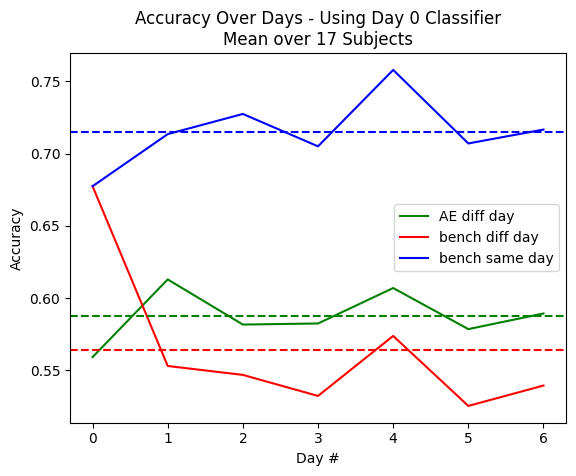

In [126]:
ok_same = []
ok_diff = []
ok_AE = []

for i in range(len(diff_list)):
    if np.mean(same_list[i]) > 0.1:
        
        if len(same_list[i]) < 7:
            continue
        ok_same.append(np.asarray(same_list[i][:]))
        ok_diff.append(np.asarray(diff_list[i][:]))
        ok_AE.append(np.asarray(AE_list[i][:]))

sub_N = len(ok_same)        
ok_same = np.mean(np.vstack(ok_same), axis = 0)
ok_diff = np.mean(np.vstack(ok_diff), axis = 0)
ok_AE = np.mean(np.vstack(ok_AE), axis = 0)


# Start from which day to plot?
plot_from = 0

# Plot
plt.plot(range(plot_from, plot_from + len(ok_diff[plot_from:])), ok_AE[plot_from:], label='AE diff day', color='g')
plt.plot(range(plot_from, plot_from + len(ok_diff[plot_from:])), ok_diff[plot_from:], label='bench diff day', color='r')
plt.plot(range(plot_from, plot_from + len(ok_diff[plot_from:])), ok_same[plot_from:], label='bench same day', color='b')

plt.axhline(y=np.mean(ok_AE[plot_from:]), color='g', linestyle='--')
plt.axhline(y=np.mean(ok_diff[plot_from:]), color='r', linestyle='--')
plt.axhline(y=np.mean(ok_same[plot_from:]), color='b', linestyle='--')

plt.title(f'Accuracy Over Days - Using Day 0 Classifier\nMean over {sub_N} Subjects')
plt.xlabel('Day #')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [121]:
_, p_01 = scipy.stats.ttest_ind(np.vstack(day_classification_score)[:,1],np.vstack(day_classification_score)[:,0])
_, p_12 = scipy.stats.ttest_ind(np.vstack(day_classification_score)[:,1],np.vstack(day_classification_score)[:,2])
_, p_02 = scipy.stats.ttest_ind(np.vstack(day_classification_score)[:,2],np.vstack(day_classification_score)[:,0])


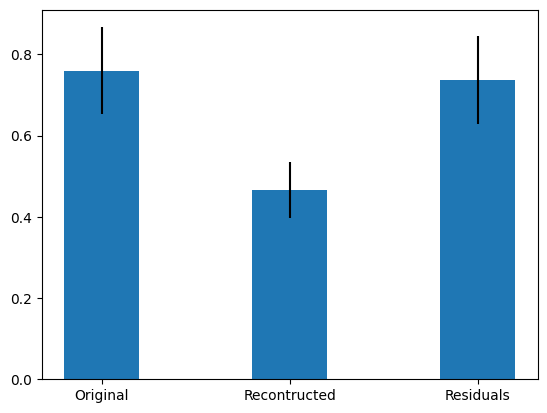

In [122]:
days_classification_mean = np.mean(np.vstack(day_classification_score), axis = 0)
days_classification_std = np.std(np.vstack(day_classification_score), axis = 0)
plt.figure()

plt.bar([2,4,6], days_classification_mean, width=0.8, align='center', tick_label=['Original', 'Recontructed', 'Residuals'],\
    yerr=days_classification_std)
plt.show()

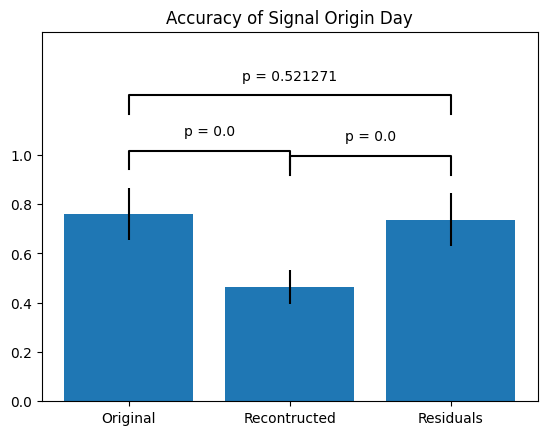

In [123]:
heights = days_classification_mean
bars = np.arange(len(heights))

plt.figure()
plt.bar(bars, heights, align='center', yerr=days_classification_std)
plt.ylim(0, 1.5)
barplot_annotate_brackets(0, 1, f'p = {np.round(p_01,decimals=6)}', bars, heights, yerr=days_classification_std)
barplot_annotate_brackets(1, 2, f'p = {np.round(p_12,decimals=6)}', bars, heights, yerr=days_classification_std)
barplot_annotate_brackets(0, 2, f'p = {np.round(p_02,decimals=6)}', bars, heights, dh=.2, yerr=days_classification_std)
plt.xticks(ticks=bars, labels=['Original', 'Recontructed', 'Residuals'])
plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.title('Accuracy of Signal Origin Day')
plt.show()

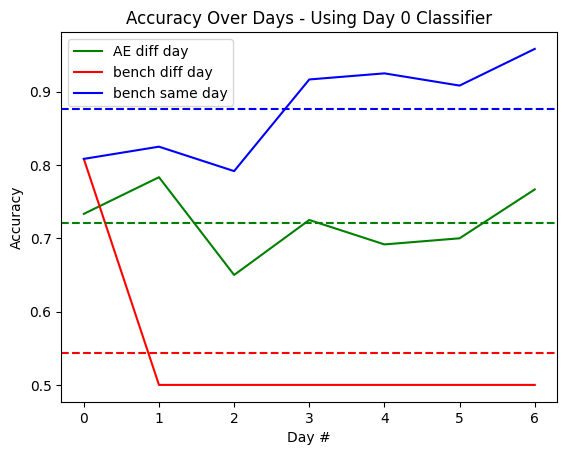

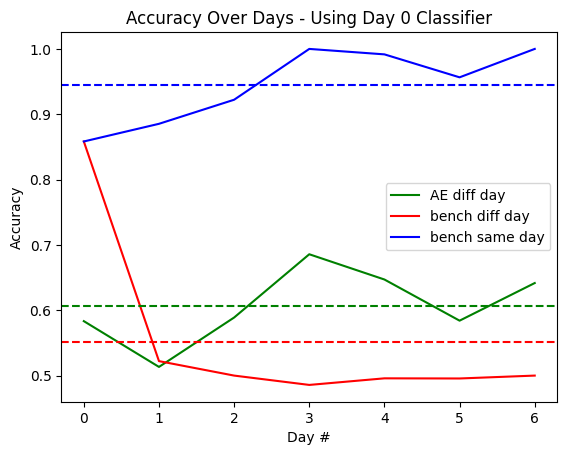

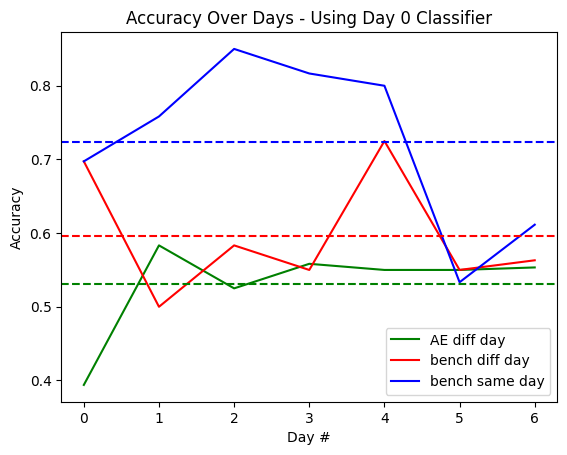

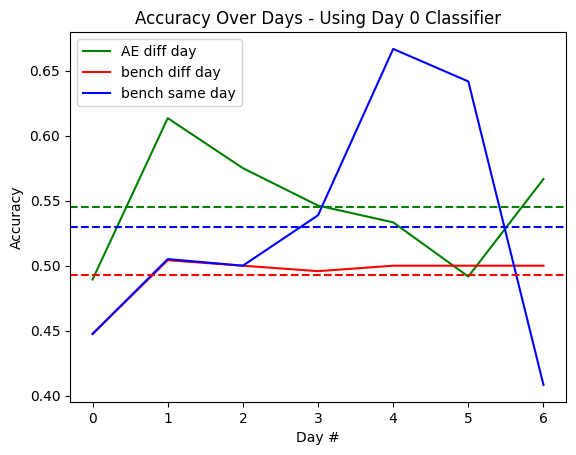

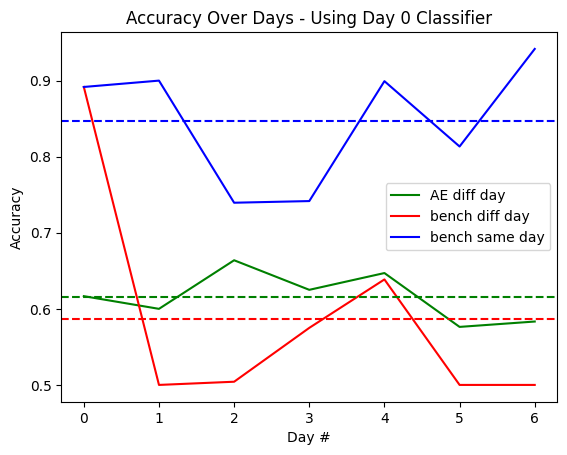

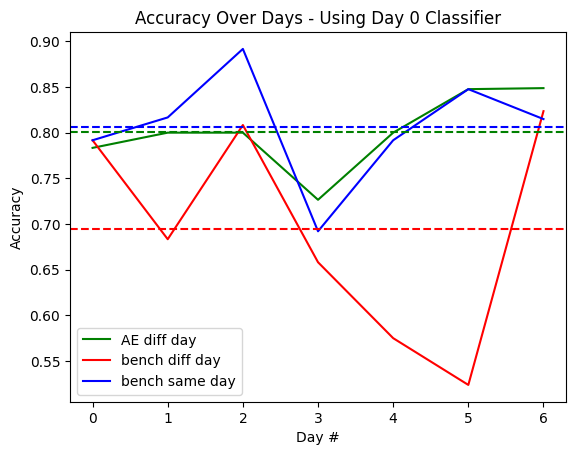

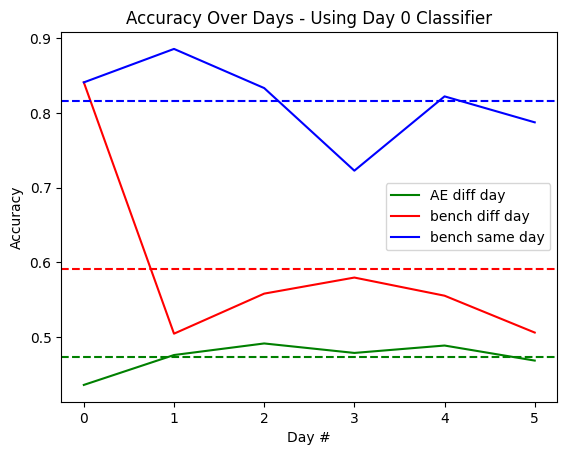

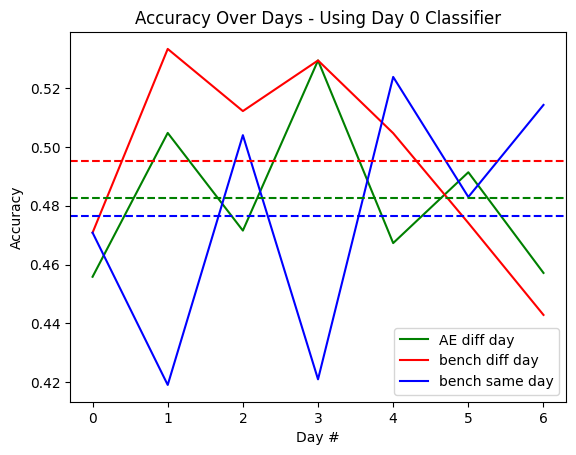

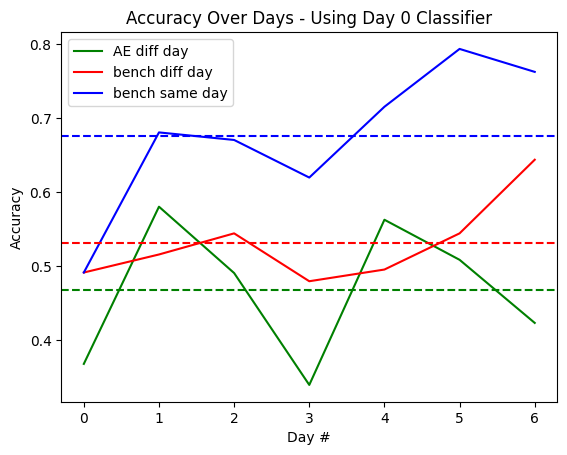

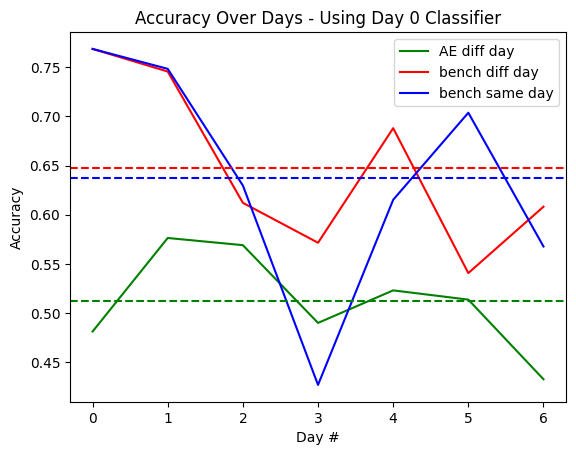

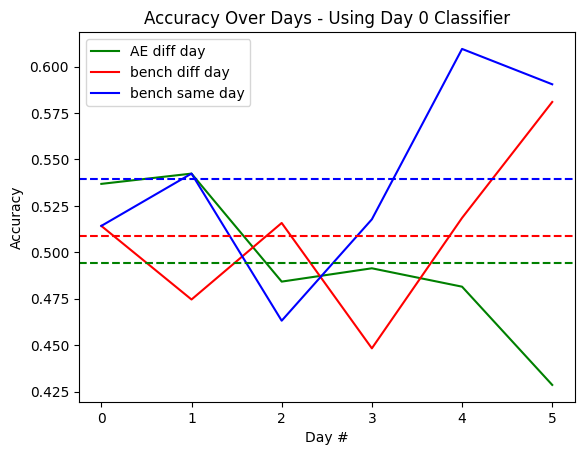

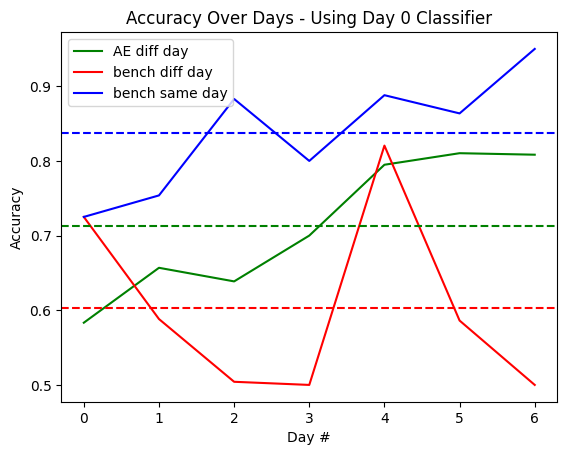

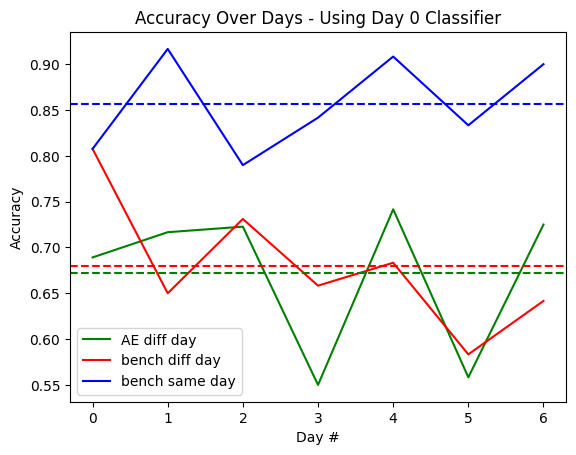

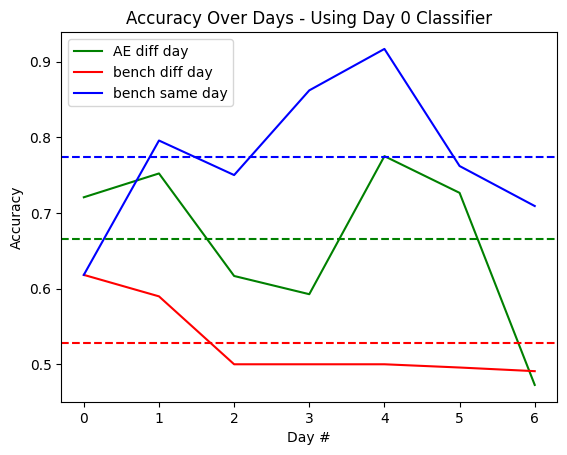

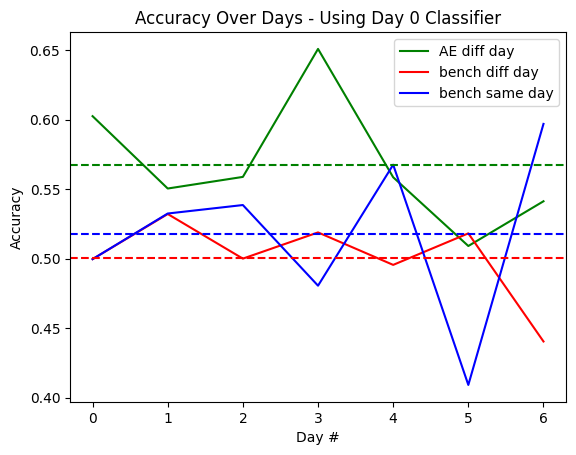

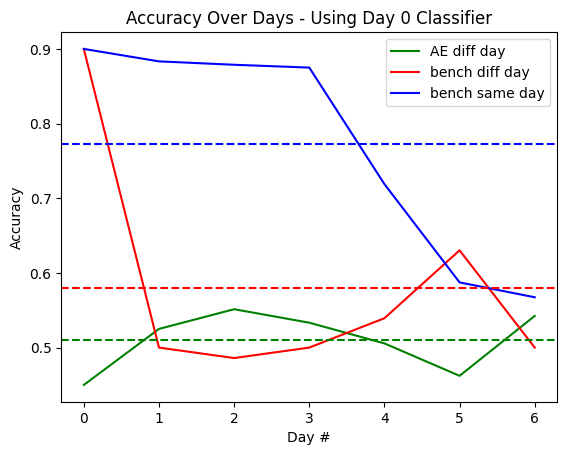

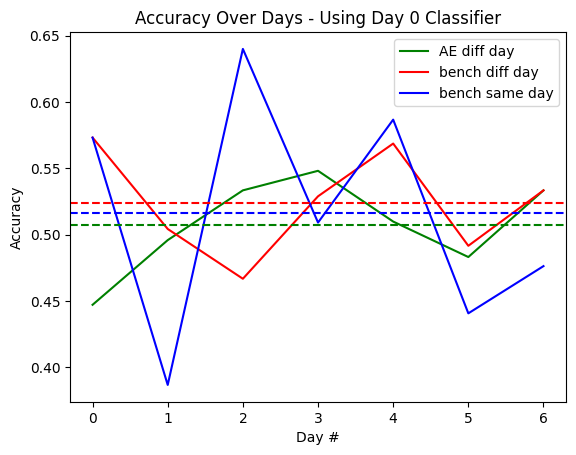

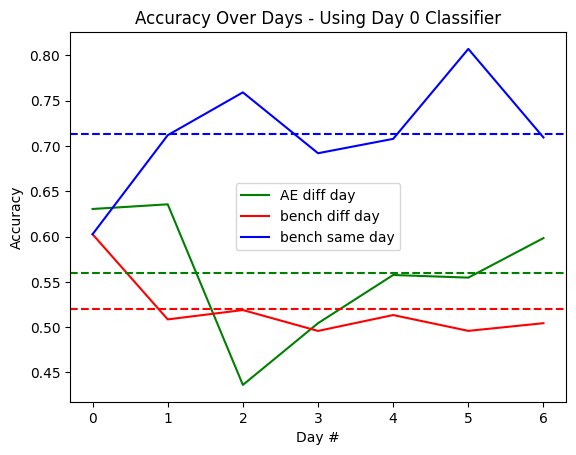

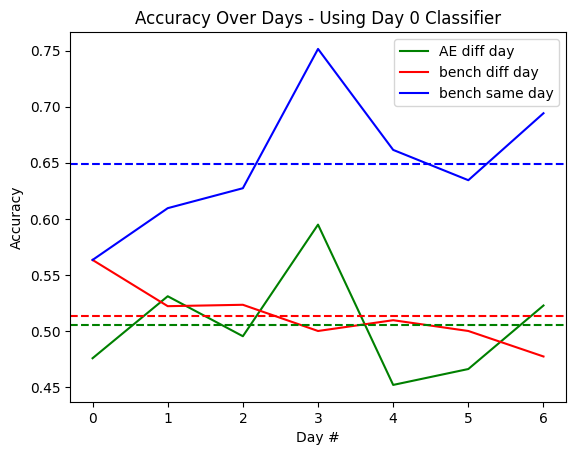

In [124]:
for i in range(len(diff_list)):
    plt.figure(i)
    # Start from which day to plot?
    plot_from = 0
    
    # Plot
    plt.plot(range(plot_from, plot_from + len(diff_list[i][plot_from:])), AE_list[i][plot_from:], label='AE diff day', color='g')
    plt.plot(range(plot_from, plot_from + len(diff_list[i][plot_from:])), diff_list[i][plot_from:], label='bench diff day', color='r')
    plt.plot(range(plot_from, plot_from + len(diff_list[i][plot_from:])), same_list[i][plot_from:], label='bench same day', color='b')

    plt.axhline(y=np.mean(AE_list[i][plot_from:]), color='g', linestyle='--')
    plt.axhline(y=np.mean(diff_list[i][plot_from:]), color='r', linestyle='--')
    plt.axhline(y=np.mean(same_list[i][plot_from:]), color='b', linestyle='--')

    plt.title('Accuracy Over Days - Using Day 0 Classifier')
    plt.xlabel('Day #')
    plt.ylabel('Accuracy')
    plt.legend()
plt.show()

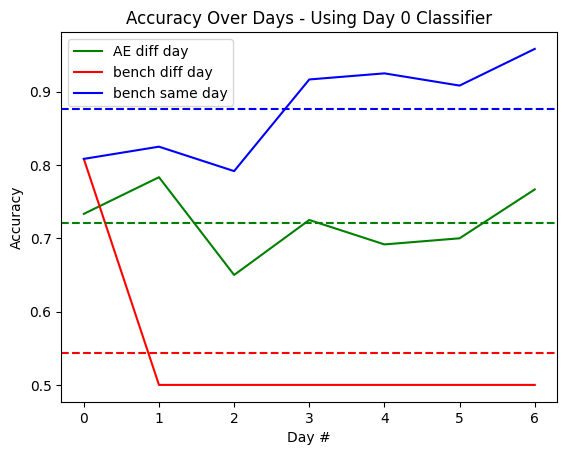

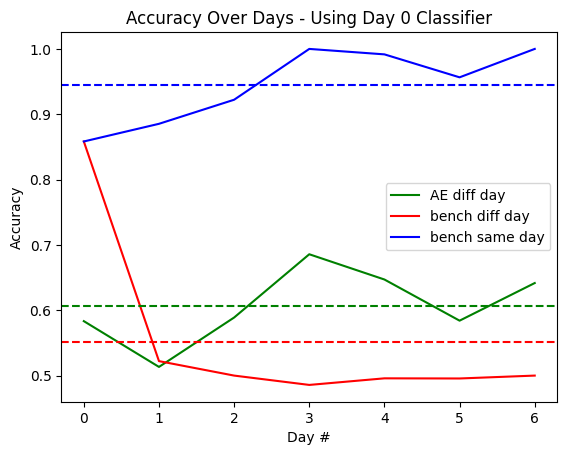

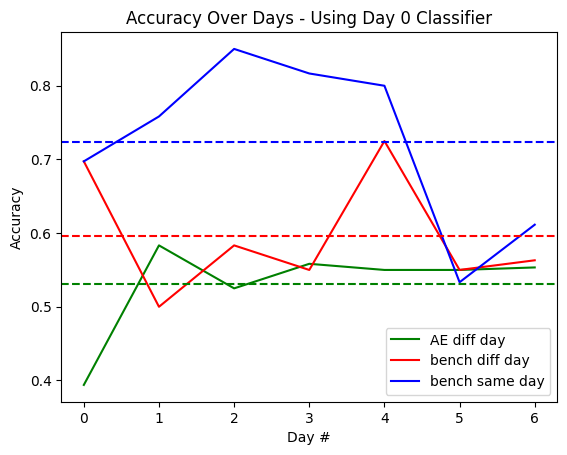

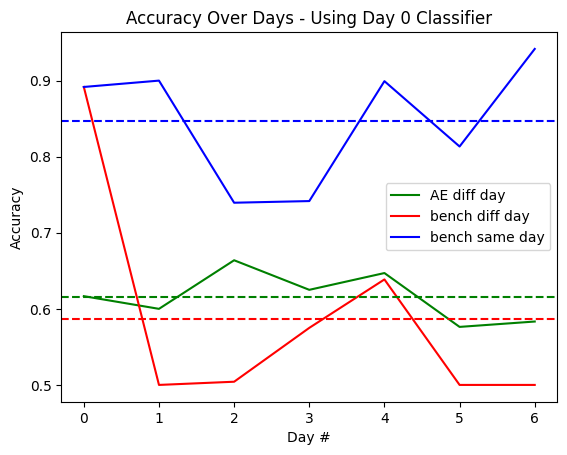

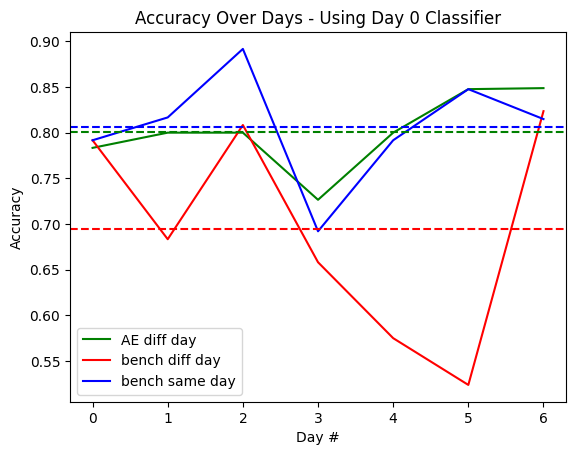

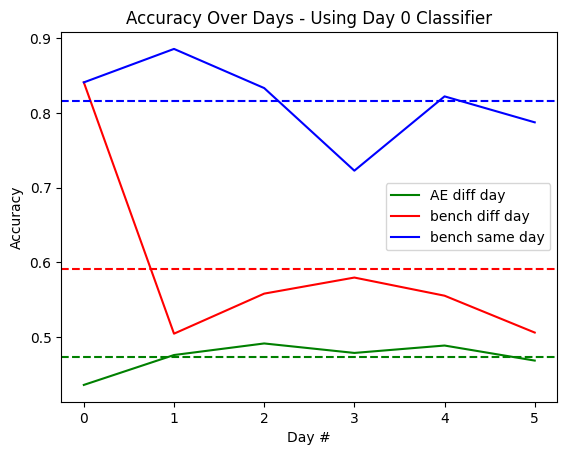

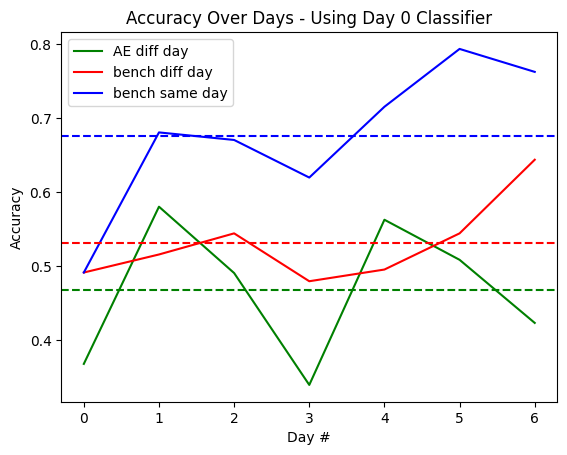

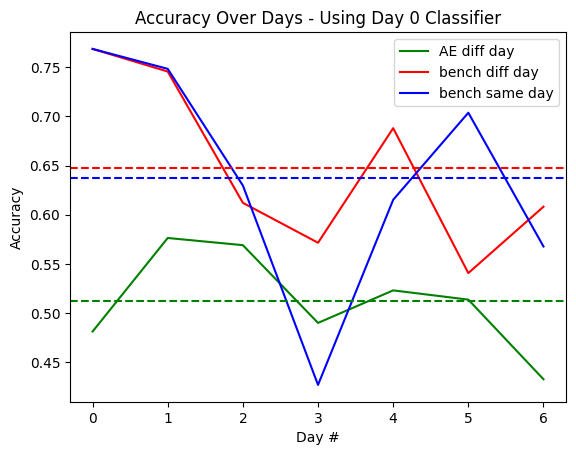

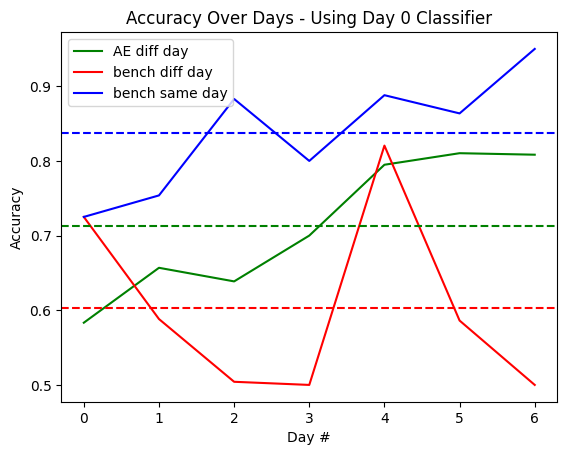

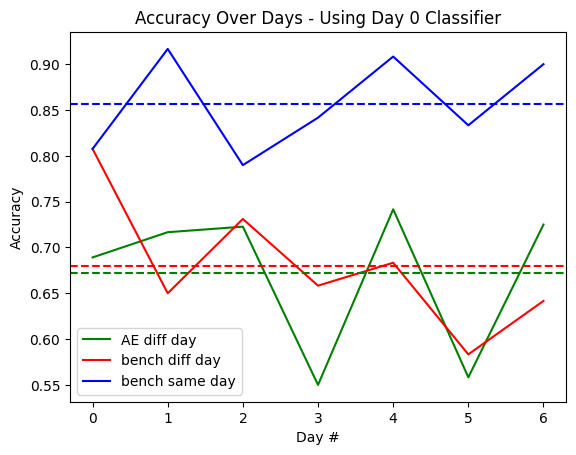

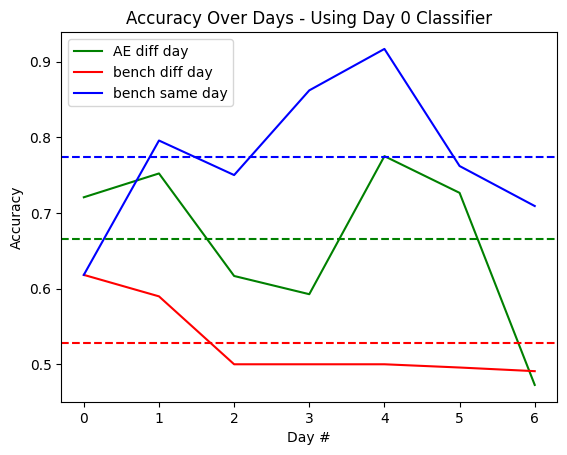

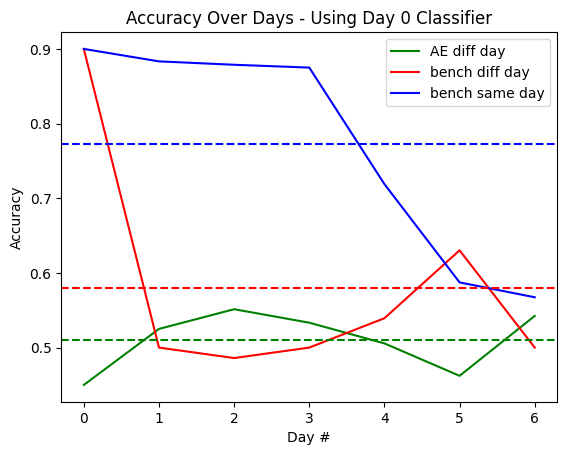

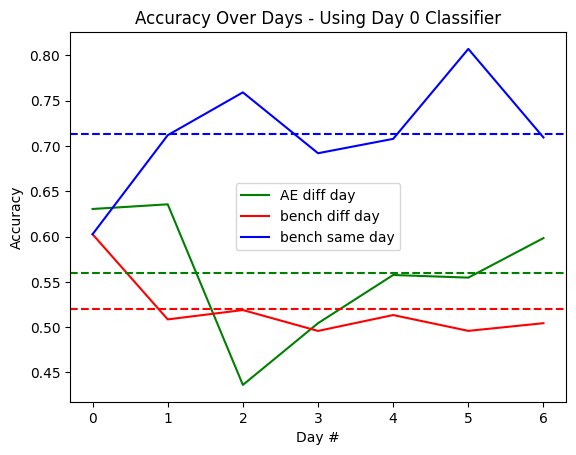

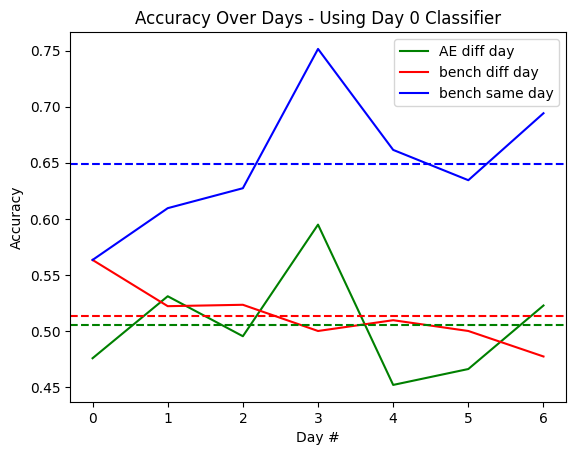

In [125]:
for i in range(len(diff_list)):
    if np.mean(same_list[i]) < 0.55:
        continue
        
    plt.figure(i)
    # Start from which day to plot?
    plot_from = 0
    
    # Plot
    plt.plot(range(plot_from, plot_from + len(diff_list[i][plot_from:])), AE_list[i][plot_from:], label='AE diff day', color='g')
    plt.plot(range(plot_from, plot_from + len(diff_list[i][plot_from:])), diff_list[i][plot_from:], label='bench diff day', color='r')
    plt.plot(range(plot_from, plot_from + len(diff_list[i][plot_from:])), same_list[i][plot_from:], label='bench same day', color='b')

    plt.axhline(y=np.mean(AE_list[i][plot_from:]), color='g', linestyle='--')
    plt.axhline(y=np.mean(diff_list[i][plot_from:]), color='r', linestyle='--')
    plt.axhline(y=np.mean(same_list[i][plot_from:]), color='b', linestyle='--')

    plt.title('Accuracy Over Days - Using Day 0 Classifier')
    plt.xlabel('Day #')
    plt.ylabel('Accuracy')
    plt.legend()
plt.show()